# ⚽ Real-World Data Challenge
## FIFA 19 — What Makes a Top Football Player?
### ⏱️ Time Allowed: 2 – 2.5 Hours &nbsp;|&nbsp; Open: Syntax Sheet &nbsp;|&nbsp; Closed: Internet

---

> **The Story:**
> EA Sports collected detailed data on **18,000+ real professional footballers** for FIFA 19.
> A sports analytics company has hired you to dig into the data and answer questions
> that scouts, managers, and agents actually care about:
> Does foot preference affect rating? Do forwards outperform defenders?
> What best predicts a player's market value?
>
> Your job: **explore, test, visualise, and brief the scouting team.**

---

### 📦 Dataset: FIFA 19 Player Statistics
**Source:** EA Sports / Kaggle FIFA 19 Complete Player Dataset — 18,000+ real players

| Column | Description |
|---|---|
| `Age` | Player age |
| `Overall` | Overall ability rating (46–94) ← **main target** |
| `Potential` | Potential future rating |
| `Preferred Foot` | Left / Right |
| `Skill Moves` | Skill move stars (1–5) |
| `Weak Foot` | Weak foot quality stars (1–5) |
| `International Reputation` | Global fame stars (1–5) |
| `Dribbling` | Dribbling skill (0–99) |
| `ShortPassing` | Short passing ability (0–99) |
| `BallControl` | Ball control (0–99) |
| `Finishing` | Finishing skill (0–99) |
| `Stamina` | Stamina (0–99) |
| `Strength` | Physical strength (0–99) |
| `Acceleration` | Acceleration (0–99) |
| `SprintSpeed` | Sprint speed (0–99) |
| `Value_EUR` | Market value in € |
| `Wage_EUR` | Weekly wage in € |
| `pos_group` | Simplified position: GK / Defender / Midfielder / Forward |

---

### 🧭 Challenge Map

| Task | Topic | Est. Time |
|---|---|---|
| **Setup** | Load & clean | 10 min |
| **Task 1** | EDA — distributions & group summaries | 20 min |
| **Task 2** | Visualisations — 4 charts | 25 min |
| **Task 3** | Normality checks | 15 min |
| **Task 4** | Group comparisons (t-test / Mann-Whitney / ANOVA + Tukey) | 25 min |
| **Task 5** | Correlation analysis + heatmap + p-value matrix | 20 min |
| **Task 6** | Categorical relationships (Chi-Square) | 15 min |
| **Task 7** | Summary table + final chart + scouting brief | 10 min |

---
```
p ≤ 0.05  →  Reject H₀   (something real is happening)
p > 0.05  →  Keep H₀     (could be random chance)
```


---
## ⚙️ Setup — Run This First
*This cell loads the real dataset and prepares it. Do not change it.*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#ploty.express  for interactive Graphs

# ── Load raw FIFA 19 data ────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/amanthedorkknight/"
       "fifa18-all-player-statistics/master/2019/data.csv")
raw = pd.read_csv(url)

# ── Clean Value and Wage (convert "€110.5M" → 110500000) ────────────────────
def parse_money(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('€', '').strip()
    if 'M' in s: return float(s.replace('M', '')) * 1_000_000
    if 'K' in s: return float(s.replace('K', '')) * 1_000
    try:    return float(s)
    except: return np.nan

raw['Value_EUR'] = raw['Value'].apply(parse_money)
raw['Wage_EUR']  = raw['Wage'].apply(parse_money)

# ── Simplify position into 4 groups ─────────────────────────────────────────
def pos_group(p):
    if pd.isna(p): return None
    p = str(p).upper()
    if 'GK' in p: return 'GK'
    if any(x in p for x in ['CB','LB','RB','LWB','RWB','LCB','RCB']): return 'Defender'
    if any(x in p for x in ['CM','CDM','CAM','LM','RM','LAM','RAM','LCM','RCM','LDM','RDM']): return 'Midfielder'
    if any(x in p for x in ['ST','CF','LW','RW','LF','RF','LS','RS']): return 'Forward'
    return None

raw['pos_group'] = raw['Position'].apply(pos_group)

# ── Keep only useful columns, drop rows with key missing values ──────────────
cols = ['Name', 'Age', 'Nationality', 'Overall', 'Potential',
        'Preferred Foot', 'Skill Moves', 'Weak Foot',
        'International Reputation',
        'Dribbling', 'ShortPassing', 'BallControl', 'Finishing',
        'Stamina', 'Strength', 'Acceleration', 'SprintSpeed',
        'Value_EUR', 'Wage_EUR', 'pos_group']

df = (raw[cols]
      .dropna(subset=['Overall', 'Age', 'Preferred Foot', 'pos_group'])
      .query("pos_group in ['GK', 'Defender', 'Midfielder', 'Forward']")
      .reset_index(drop=True))

print("✅ Dataset ready!")
print(f"   Players : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print()
print(df['pos_group'].value_counts().to_string())
df.head()


✅ Dataset ready!
   Players : 18,147
   Columns : 20

pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025


,Name,Age,Nationality,Overall,Potential,Preferred Foot,Skill Moves,Weak Foot,International Reputation,Dribbling,ShortPassing,BallControl,Finishing,Stamina,Strength,Acceleration,SprintSpeed,Value_EUR,Wage_EUR,pos_group
0,L. Messi,31,Argentina,94,94,Left,4.0,4.0,5.0,97.0,90.0,96.0,95.0,72.0,59.0,91.0,86.0,110500000.0,565000.0,Forward
1,Cristiano Ronaldo,33,Portugal,94,94,Right,5.0,4.0,5.0,88.0,81.0,94.0,94.0,88.0,79.0,89.0,91.0,77000000.0,405000.0,Forward
2,Neymar Jr,26,Brazil,92,93,Right,5.0,5.0,5.0,96.0,84.0,95.0,87.0,81.0,49.0,94.0,90.0,118500000.0,290000.0,Forward
3,De Gea,27,Spain,91,93,Right,1.0,3.0,4.0,18.0,50.0,42.0,13.0,43.0,64.0,57.0,58.0,72000000.0,260000.0,GK
4,K. De Bruyne,27,Belgium,91,92,Right,4.0,5.0,4.0,86.0,92.0,91.0,82.0,90.0,75.0,78.0,76.0,102000000.0,355000.0,Midfielder


---
## 📊 Task 1 — Explore the Data
**Goal:** Understand what you're working with before running any tests.

---

### 1a. Basic Inspection

Write code to answer:
1. How many players and columns are in `df`?
2. Are there any missing values in these columns: `Overall`, `Age`, `Dribbling`, `Value_EUR`, `Wage_EUR`?
3. What is the average, minimum, and maximum **Overall** rating?
4. How many players are in each **position group** (`pos_group`)?

💡 **Hints:** `.shape` · `.isnull().sum()` · `.describe()` · `.value_counts()`


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18147 entries, 0 to 18146
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      18147 non-null  object 
 1   Age                       18147 non-null  int64  
 2   Nationality               18147 non-null  object 
 3   Overall                   18147 non-null  int64  
 4   Potential                 18147 non-null  int64  
 5   Preferred Foot            18147 non-null  object 
 6   Skill Moves               18147 non-null  float64
 7   Weak Foot                 18147 non-null  float64
 8   International Reputation  18147 non-null  float64
 9   Dribbling                 18147 non-null  float64
 10  ShortPassing              18147 non-null  float64
 11  BallControl               18147 non-null  float64
 12  Finishing                 18147 non-null  float64
 13  Stamina                   18147 non-null  float64
 14  Streng

In [ ]:
# 1a — Basic Inspection
df.shape


(18147, 20)

In [ ]:
df['Overall'].agg(['mean', 'min', 'max'])


,Overall
mean,66.253926
min,46.000000
max,94.000000


In [ ]:
print(df['pos_group'].value_counts().to_string())


pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025


In [ ]:
df[df.duplicated()]

,Name,Age,Nationality,Overall,Potential,Preferred Foot,Skill Moves,Weak Foot,International Reputation,Dribbling,ShortPassing,BallControl,Finishing,Stamina,Strength,Acceleration,SprintSpeed,Value_EUR,Wage_EUR,pos_group


---
### 1b. Group Summaries

Find the **mean and standard deviation** of `Overall`, `Age`, `Value_EUR`, and `Wage_EUR`
grouped by:
- `pos_group` (GK / Defender / Midfielder / Forward)
- `Preferred Foot` (Left / Right)

💡 **Hint:** `df.groupby('col')[['Overall','Age']].agg(['mean','std']).round(2)`


In [ ]:
df.groupby('pos_group')[['Overall','Age','Value_EUR','Wage_EUR']].agg(['mean','std']).round(2)

Overall          Age         Value_EUR              Wage_EUR  \
              mean   std   mean   std        mean         std      mean   
pos_group                                                                 
Defender     66.40  6.46  25.47  4.52  1975138.08  4106420.51   9146.10   
Forward      66.40  7.02  24.66  4.61  2984155.94  7395815.54  11718.26   
GK           64.60  7.60  26.04  5.47  1585814.81  4562890.61   6803.95   
Midfielder   66.55  6.96  24.78  4.51  2760639.08  5890612.59  10180.61   

                      
                 std  
pos_group             
Defender    18970.31  
Forward     28662.56  
GK          16719.63  
Midfielder  21932.88

In [ ]:
df.groupby('Preferred Foot')[['Overall','Age','Value_EUR','Wage_EUR']].agg(['mean','std']).round(2)


Overall          Age         Value_EUR              Wage_EUR  \
                  mean   std   mean   std        mean         std      mean   
Preferred Foot                                                                
Left             66.80  6.56  25.10  4.52  2588727.73  5956115.19  10353.29   
Right            66.09  7.01  25.13  4.71  2366090.90  5490850.79   9579.57   

                          
                     std  
Preferred Foot            
Left            23656.32  
Right           21512.73

---
### 1c. Written Observations ✍️

Fill in the blanks after running your code:

```
1. The dataset has 18147 players and 20 columns.

2. Missing values found in:
   Overall 0  Age 0  Dribbling 0
   Value_EUR 0  Wage_EUR 0

3. Overall rating → Mean: 66.25  Min: 46.00  Max: 94.00

4. Position group counts:
   GK: 2025   Defender: 5866   Midfielder: 6838   Forward: 3418

5. Which position group has the highest average Overall? Midfielder

6. Do left-footed or right-footed players have a higher average Overall?
   66.80  by 66.09  rating points.
```


---
## 🎨 Task 2 — Visualisations
**Goal:** See the data. Statistics without charts are blind.

---

### 2a. The Big Four — 2×2 Subplot Grid

Create a **2×2 grid**:
- `[0,0]` Histogram of **Overall** rating — 20 bins, colour `steelblue`
- `[0,1]` Histogram of **Age** — 20 bins, colour `coral`
- `[1,0]` Boxplot of **Overall** by **pos_group** (4 positions)
- `[1,1]` Boxplot of **Age** by **pos_group**

Every subplot needs **title, xlabel, ylabel**. Write one `# observation:` comment per plot.

💡 **Hints:**  
`ax.hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')`  
`df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])`  
`plt.suptitle(...)` · `plt.tight_layout()`


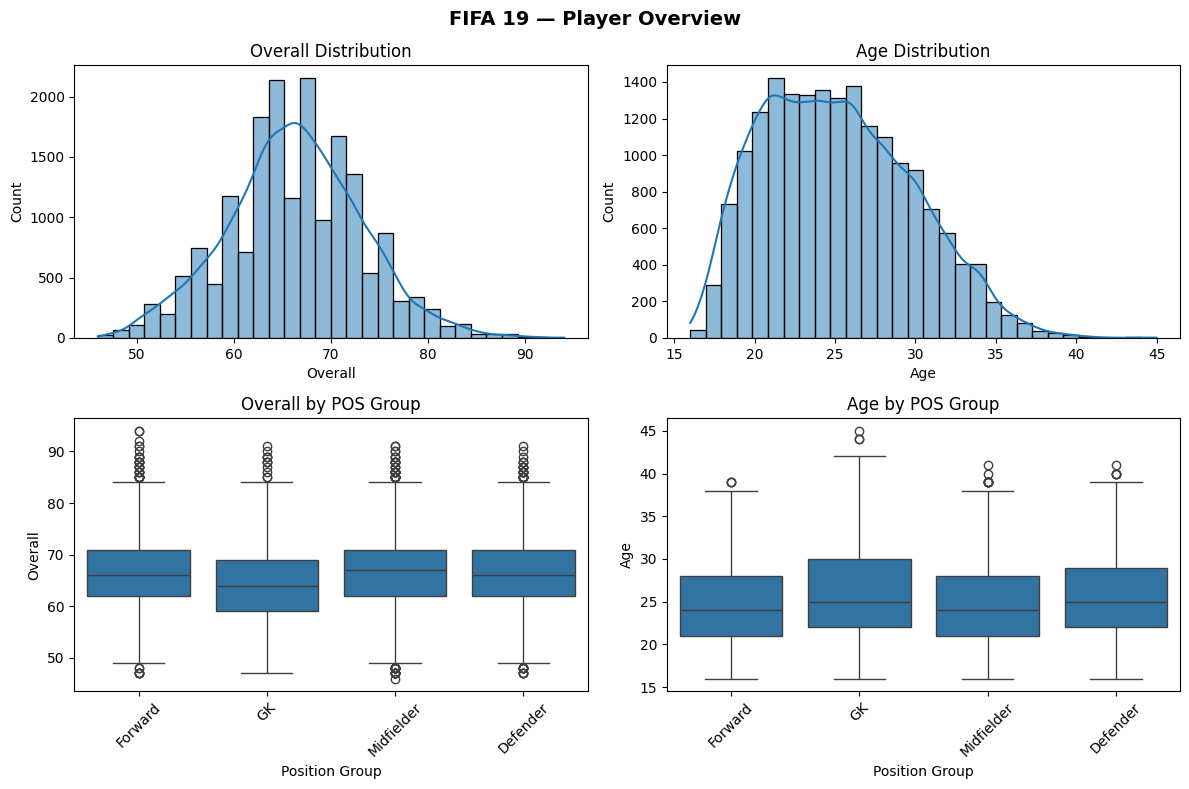

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2a — 2×2 Subplot Grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [0,0] Histogram of Overall
# observation:
sns.histplot(df['Overall'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Overall Distribution')
axes[0,0].set_xlabel('Overall')
axes[0,0].set_ylabel('Count')

# [0,1] Histogram of Age
# observation:
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Count')

# [1,0] Boxplot: Overall by pos_group
# observation:
sns.boxplot(x='pos_group', y='Overall', data=df, ax=axes[1,0])
axes[1,0].set_title('Overall by POS Group')
axes[1,0].set_xlabel('Position Group')
axes[1,0].set_ylabel('Overall')
axes[1,0].tick_params(axis='x', rotation=45)

# [1,1] Boxplot: Age by pos_group
# observation:
sns.boxplot(x='pos_group', y='Age', data=df, ax=axes[1,1])
axes[1,1].set_title('Age by POS Group')
axes[1,1].set_xlabel('Position Group')
axes[1,1].set_ylabel('Age')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('FIFA 19 — Player Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
### 2b. Scatter Plot — Age vs Overall Rating

Create a scatter plot of **Age** (x) vs **Overall** (y).
- Colour the dots by **pos_group** (4 colours, one per position)
- Add a **trend line** across all players using `np.polyfit`
- Proper title, xlabel, ylabel, legend

💡 **Hints:**  
`sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax)`  
`m, b = np.polyfit(df['Age'], df['Overall'], 1)`  
`x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)`  
`ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')`

> After plotting — does the trend line go up or down? What does that mean for a player's career?


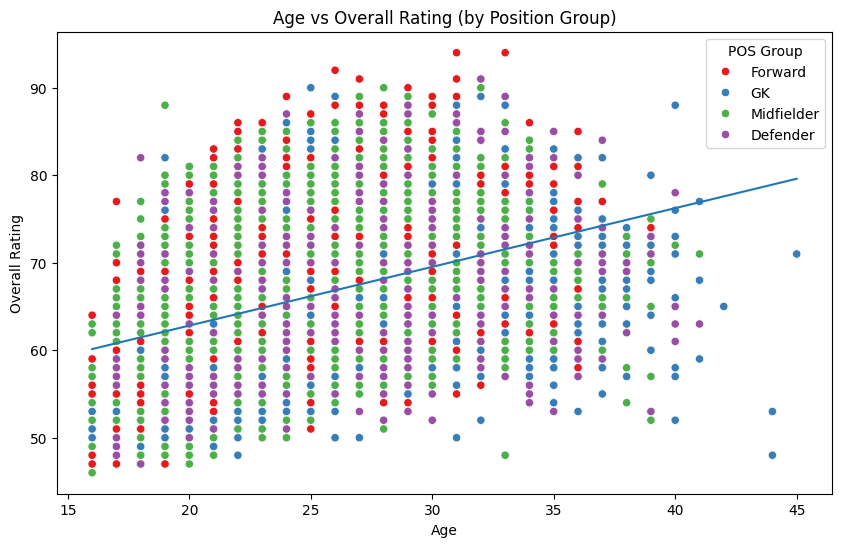

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Overall',
    hue='pos_group',
    palette='Set1'
)
clean_df = df[['Age', 'Overall']].dropna()
m, b = np.polyfit(clean_df['Age'], clean_df['Overall'], 1)
x_vals = np.linspace(clean_df['Age'].min(), clean_df['Age'].max(), 100)
y_vals = m * x_vals + b
plt.plot(x_vals, y_vals)

plt.title('Age vs Overall Rating (by Position Group)')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.legend(title='POS Group')

plt.show()

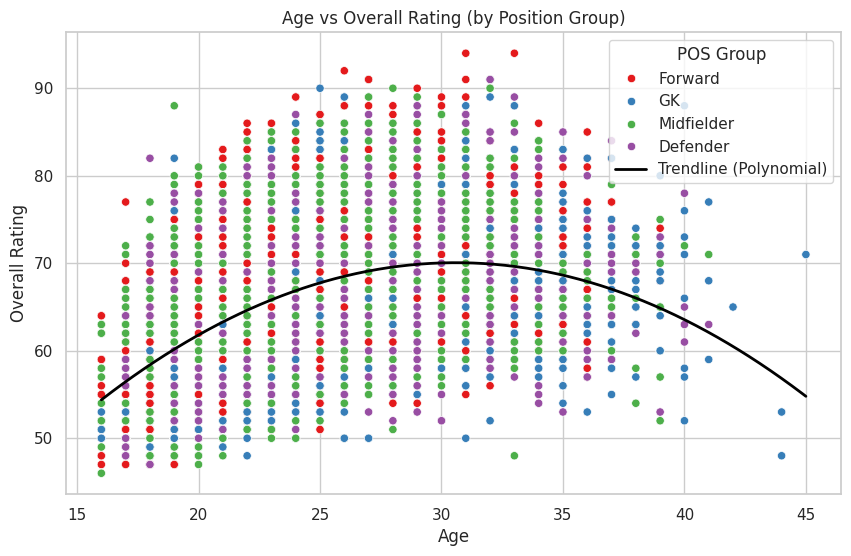

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(10,6))

# Scatter plot by position group
sns.scatterplot(
    data=df,
    x='Age',
    y='Overall',
    hue='pos_group',
    palette='Set1'
)

# Clean data
clean_df = df[['Age', 'Overall']].dropna()

# Polynomial regression (degree=2)
coeffs = np.polyfit(clean_df['Age'], clean_df['Overall'], deg=2)
poly_func = np.poly1d(coeffs)

# Create smooth x values and predict y
x_vals = np.linspace(clean_df['Age'].min(), clean_df['Age'].max(), 200)
y_vals = poly_func(x_vals)

# Plot the polynomial trendline
plt.plot(x_vals, y_vals, color='black', linewidth=2, label='Trendline (Polynomial)')

plt.title('Age vs Overall Rating (by Position Group)')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.legend(title='POS Group')

plt.show()

---
### 2c. Bar Chart — Average Overall by Position (with Error Bars)

Create a **bar chart** showing the average Overall for each `pos_group`.
- Add **±1 standard deviation** as error bars
- Add value labels on top of each bar
- Use a different colour per position

💡 **Hints:**
```python
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()
ax.bar(grouped['pos_group'], grouped['mean'],
       yerr=grouped['std'], capsize=5, color=[...], edgecolor='black')
for bar, m in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, m + 1, f'{m:.1f}', ha='center')
```


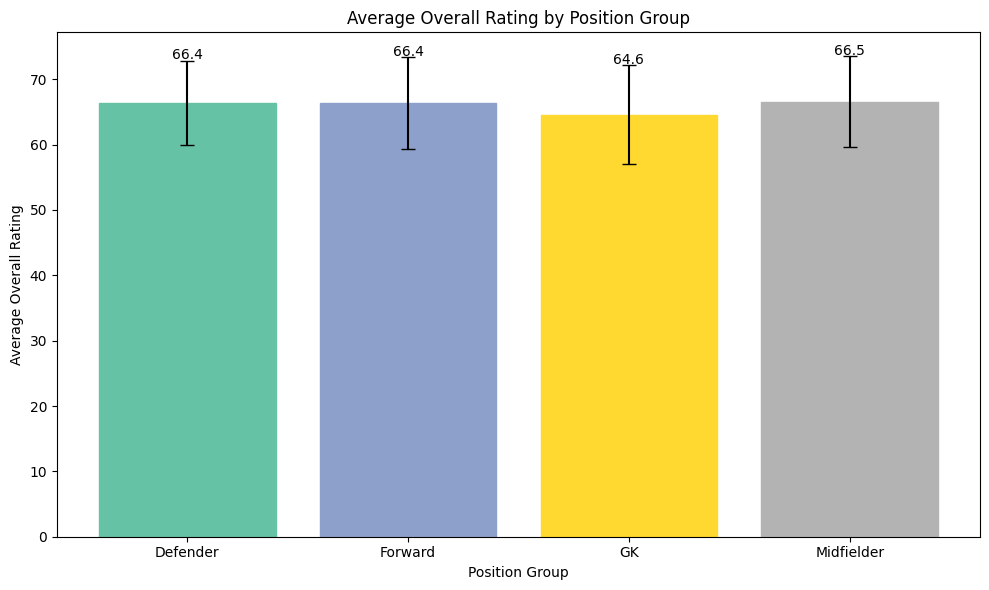

In [ ]:
# Group data

grouped = df.groupby('pos_group')['Overall'].agg(['mean', 'std']).reset_index()
plt.figure(figsize=(10,6))

bars = plt.bar(
    grouped['pos_group'],
    grouped['mean'],
    yerr=grouped['std'],
    capsize=5
)

colors = plt.cm.Set2(np.linspace(0, 1, len(grouped)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

for i, row in grouped.iterrows():
    plt.text(
        i,
        row['mean'] + row['std'] + 0.2,
        f"{row['mean']:.1f}",
        ha='center'
    )

plt.title('Average Overall Rating by Position Group')
plt.xlabel('Position Group')
plt.ylabel('Average Overall Rating')

plt.tight_layout()
plt.show()

---
## 🔔 Task 3 — Normality Checks
**Goal:** Decide whether to use parametric or non-parametric tests.

---

### 3a. Shapiro-Wilk Test

Run Shapiro-Wilk on: `Overall`, `Age`, `Dribbling`, `Strength`, `Value_EUR`

> ⚠️ **Note:** Shapiro-Wilk is designed for small samples. On large datasets (n > 5000),
> it almost always gives p ≈ 0. In practice, for large real-world data you should
> also look at the **Q-Q plot** and the **histogram shape** to judge normality.
> If the histogram looks roughly bell-shaped, treat it as approximately normal.

Print a clean table with column name, p-value, and your judgement.

💡 **Hints:** `stat, p = stats.shapiro(df['col'].sample(500, random_state=42))` — sample 500 rows for Shapiro


In [ ]:
import pandas as pd
from scipy import stats

cols = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

results = []

for col in cols:
    sample_data = df[col].dropna().sample(500, random_state=42)

    stat, p = stats.shapiro(sample_data)
    if p > 0.05:
        judgement = 'Approximately Normal'
    else:
        judgement = 'Not Normal'

    results.append([col, p, judgement])

# Create clean table
results_df = pd.DataFrame(results, columns=['Column', 'p-value', 'Judgement'])

print(results_df)

      Column       p-value   Judgement
0    Overall  1.650857e-02  Not Normal
1        Age  8.493848e-08  Not Normal
2  Dribbling  2.567858e-20  Not Normal
3   Strength  4.886808e-06  Not Normal
4  Value_EUR  2.770776e-35  Not Normal


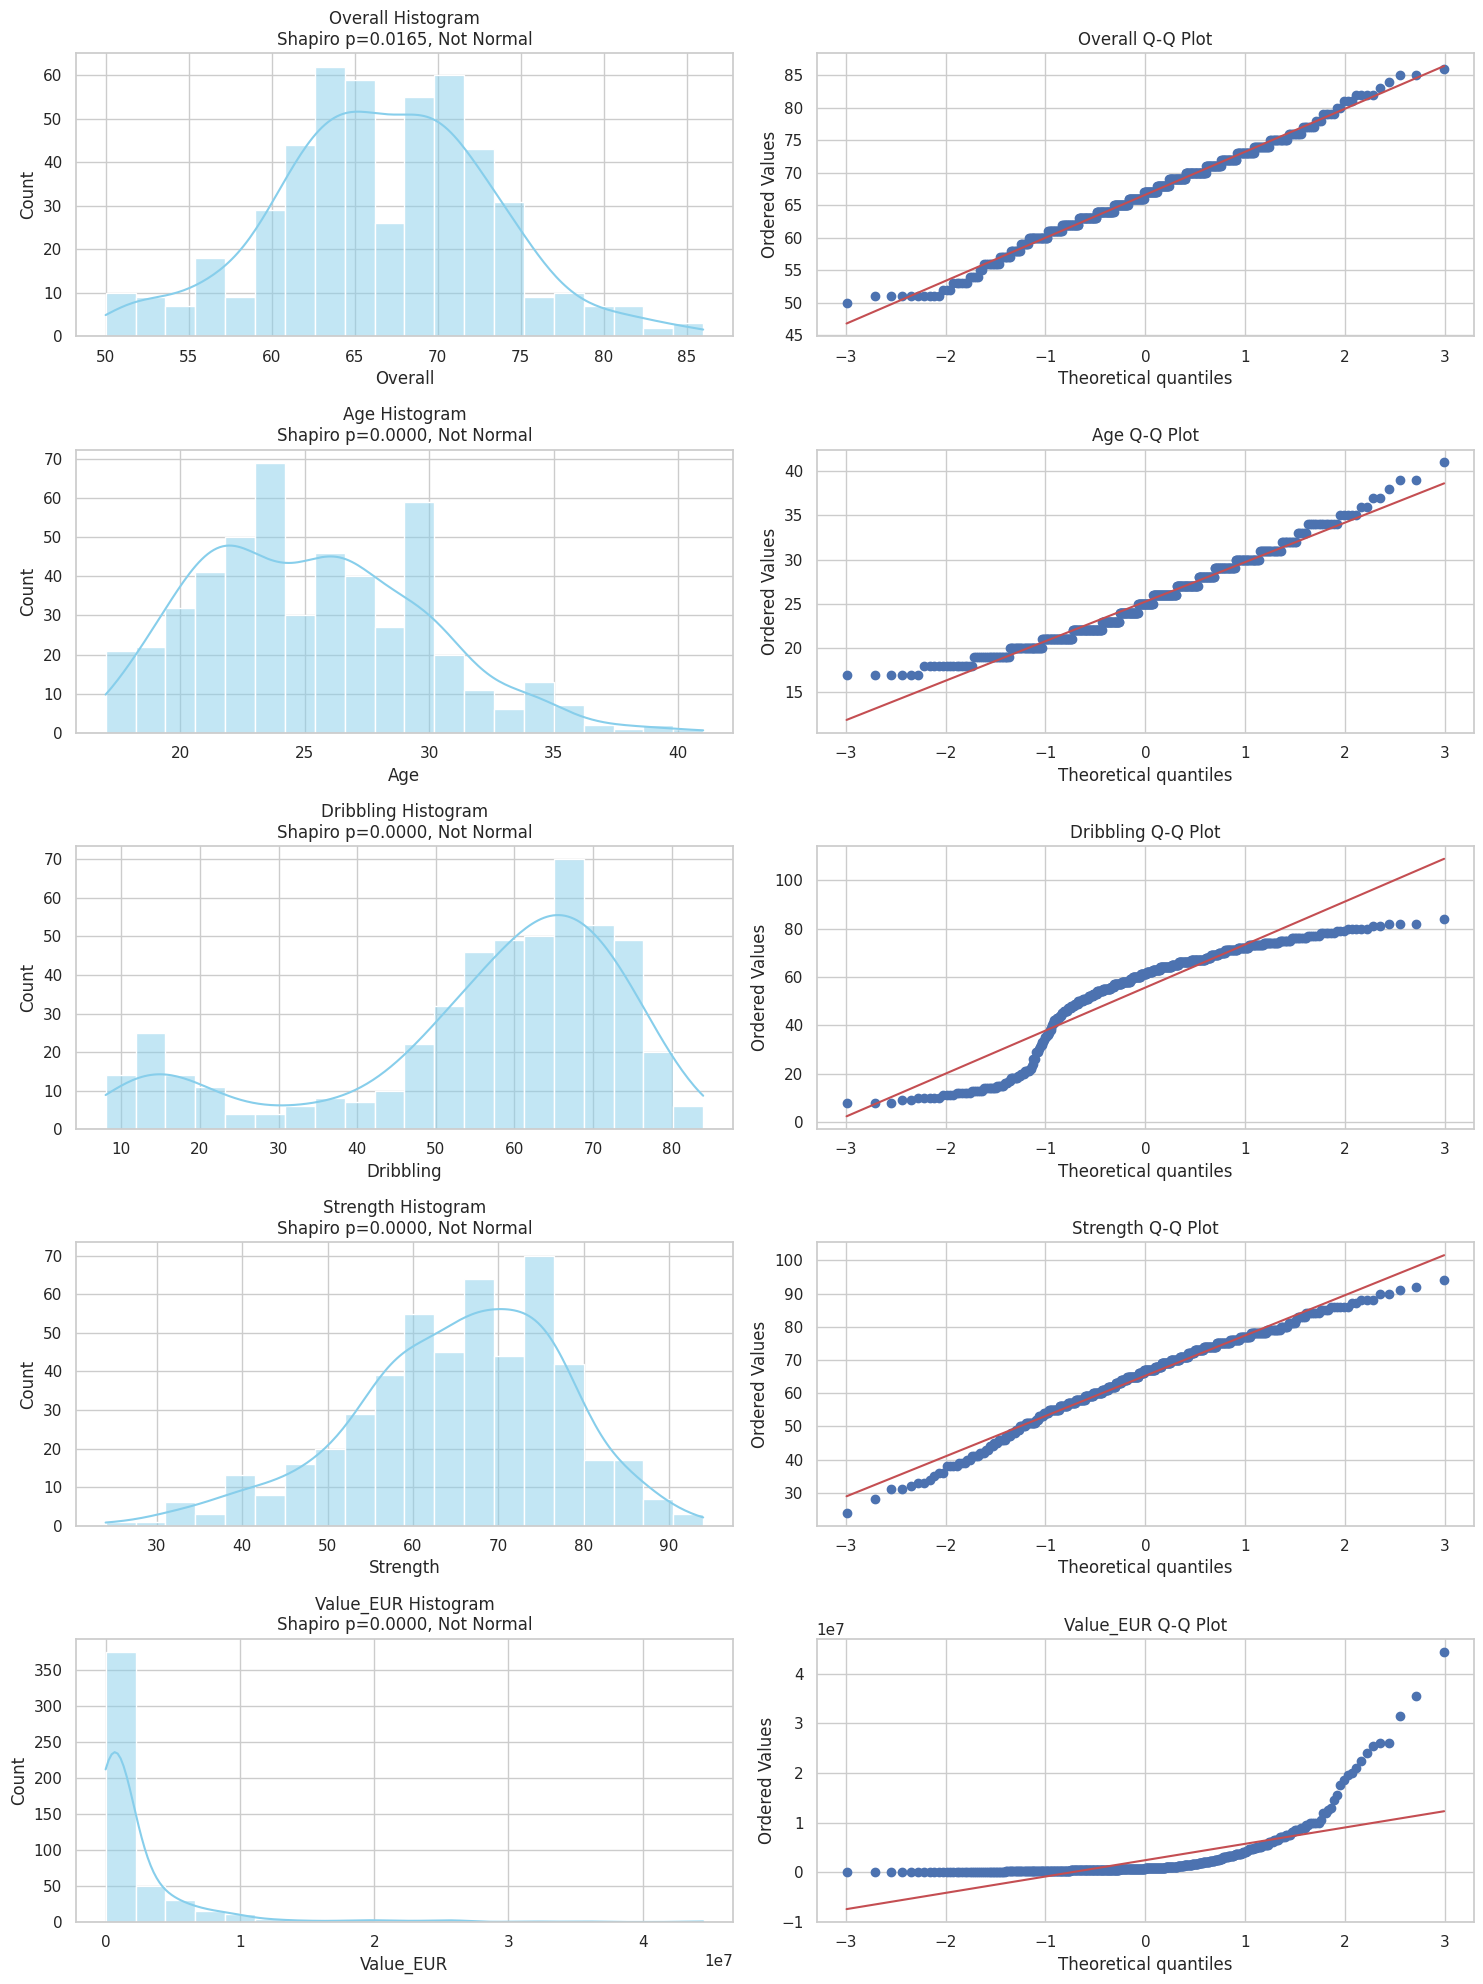

      Column       p-value   Judgement
0    Overall  1.650857e-02  Not Normal
1        Age  8.493848e-08  Not Normal
2  Dribbling  2.567858e-20  Not Normal
3   Strength  4.886808e-06  Not Normal
4  Value_EUR  2.770776e-35  Not Normal


In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import stats
# import seaborn as sns

cols = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

results = []

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(15, len(cols)*4))

for i, col in enumerate(cols, 1):
    # Sample 500 values
    sample_data = df[col].dropna().sample(500, random_state=42)

    # Shapiro-Wilk test
    stat, p = stats.shapiro(sample_data)
    judgement = 'Approximately Normal' if p > 0.05 else 'Not Normal'
    results.append([col, p, judgement])

    # Histogram
    plt.subplot(len(cols), 2, 2*i-1)
    sns.histplot(sample_data, kde=True, color='skyblue', bins=20)
    plt.title(f'{col} Histogram\nShapiro p={p:.4f}, {judgement}')

    # Q-Q plot
    plt.subplot(len(cols), 2, 2*i)
    stats.probplot(sample_data, dist="norm", plot=plt)
    plt.title(f'{col} Q-Q Plot')

# Adjust layout
plt.tight_layout()
plt.show()

# Results table
results_df = pd.DataFrame(results, columns=['Column', 'p-value', 'Judgement'])
print(results_df)

---
### 3b. Q-Q Plots

Create a **1×5 grid of Q-Q plots** for the same five columns.
- Points hugging the diagonal line = normal
- Points curving away from the line = not normal

💡 **Hint:** `stats.probplot(df['col'].dropna(), plot=axes[i])`


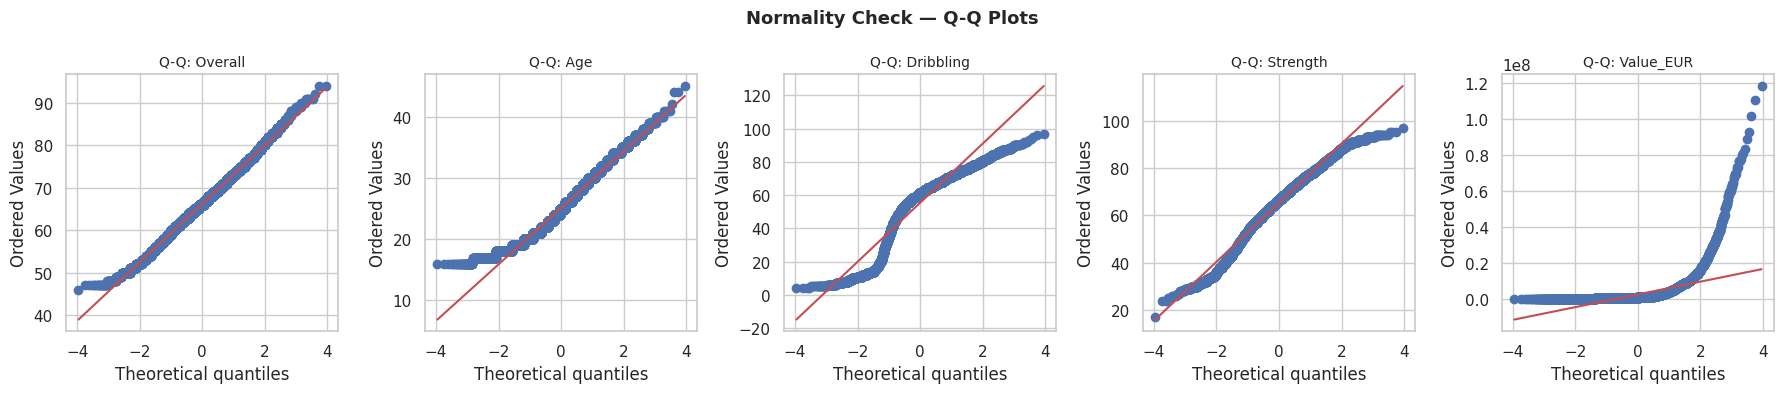

In [ ]:
# 3b — Q-Q Plots
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']):
    stats.probplot(df[col].dropna(), plot=axes[i])
    axes[i].set_title(f'Q-Q: {col}', fontsize=10)

plt.suptitle('Normality Check — Q-Q Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
### 3c. Your Decision Table ✍️

Fill this in — it determines which tests you use in Tasks 4 and 5:

| Column | Histogram Shape | Q-Q Shape | Treat as Normal? | → Use for groups | → Use for relationship |
|---|---|---|---|---|---|
| Overall |Slight Left Skewed |Mostly Linear |Yes | t-test / Mann-Whitney | Pearson / Spearman |
| Age| slightly right skwed | Deviated in tail | No |Mann-Whiney | SpearMan |
| Dribbling |Slight left skwed |Mostly Linear |Yes |t-test/ Anova |Pearson |
| Strength |Slight Left Skewd | Mostly Linear |Yes |t-test |Pearson |
| Value_EUR |Strong Right Skewed | Deviates in Tail |No | Kruskal-Wallis |Spearman |

> 💡 If ANY group in a comparison is non-normal → use non-parametric.


---
## 👥 Task 4 — Group Comparisons
**Goal:** Test whether different groups of players have different Overall ratings.

---

### 4a. Do Left-Footed vs Right-Footed Players Differ in Overall?

**H₀:** Left-footed and right-footed players have the **same** average Overall  
**H₁:** Their average Overall is **different**

Steps:
1. Extract Overall for each foot group
2. Check normality of each group (Shapiro — sample 500)
3. Based on normality → choose **t-test** or **Mann-Whitney U**
4. Run the test, print statistic, p-value, verdict

💡 **Hints:**  
`left  = df[df['Preferred Foot'] == 'Left']['Overall']`  
`stats.ttest_ind(left, right)` or `stats.mannwhitneyu(left, right, alternative='two-sided')`

p < 0.05 → Reject H₀ → Significant difference
p ≥ 0.05 → Fail to reject H₀ → No difference


In [ ]:
from scipy import stats

left = df[df['Preferred Foot'] == 'Left']['Overall'].dropna()
right = df[df['Preferred Foot'] == 'Right']['Overall'].dropna()

left_sample = left.sample(min(500, len(left)), random_state=42)
right_sample = right.sample(min(500, len(right)), random_state=42)

stat_l, p_l = stats.shapiro(left_sample)
stat_r, p_r = stats.shapiro(right_sample)

print(f"Left p-value: {p_l}")
print(f"Right p-value: {p_r}")

# ---- Step 3: Choose test ----
if p_l > 0.05 and p_r > 0.05:
    print("\nUsing Independent t-test")
    stat, p = stats.ttest_ind(left, right, equal_var=False)  # Welch's t-test (safer)
    test_name = "t-test"
else:
    print("\nUsing Mann-Whitney U test")
    stat, p = stats.mannwhitneyu(left, right, alternative='two-sided')
    test_name = "Mann-Whitney U"

# ---- Step 4: Result ----
print(f"\nTest: {test_name}")
print(f"Statistic: {stat}")
print(f"p-value: {p}")

# ---- Step 5: Verdict ----
alpha = 0.05
if p < alpha:
    print("Reject H0 → Significant difference in Overall ratings")
else:
    print("Fail to reject H0 → No significant difference in Overall ratings")

Left p-value: 0.008233109680225652
Right p-value: 0.054662258024980474

Using Mann-Whitney U test

Test: Mann-Whitney U
Statistic: 30999381.0
p-value: 2.1209578064212897e-08
Reject H0 → Significant difference in Overall ratings


---
### 4b. Do Forwards Score Higher in Overall than Defenders?

Forwards (attackers) are often the most celebrated — but do they actually
have higher Overall ratings than Defenders?

**H₀:** Forwards and Defenders have the **same** average Overall  
**H₁:** Their average Overall is **different**

Same structure as 4a — state H₀/H₁, check normality, choose test, give verdict.


In [ ]:
from scipy import stats

# ---- Step 1: Extract groups ----
forwards = df[df['pos_group'] == 'Forward']['Overall'].dropna()
defenders = df[df['pos_group'] == 'Defender']['Overall'].dropna()

# ---- Step 2: Normality check (sample 500 each) ----
f_sample = forwards.sample(min(500, len(forwards)), random_state=42)
d_sample = defenders.sample(min(500, len(defenders)), random_state=42)

stat_f, p_f = stats.shapiro(f_sample)
stat_d, p_d = stats.shapiro(d_sample)

print(f"Forwards p-value: {p_f}")
print(f"Defenders p-value: {p_d}")

# ---- Step 3: Choose test ----
if p_f > 0.05 and p_d > 0.05:
    print("\nUsing Independent t-test")
    stat, p = stats.ttest_ind(forwards, defenders, equal_var=False)
    test_name = "t-test"
else:
    print("\nUsing Mann-Whitney U test")
    stat, p = stats.mannwhitneyu(forwards, defenders, alternative='two-sided')
    test_name = "Mann-Whitney U"

# ---- Step 4: Results ----
print(f"\nTest: {test_name}")
print(f"Statistic: {stat}")
print(f"p-value: {p}")

# ---- Step 5: Verdict ----
alpha = 0.05
if p < alpha:
    print("Reject H0 → Significant difference in Overall ratings")
else:
    print("Fail to reject H0 → No significant difference in Overall ratings")

Forwards p-value: 0.38515143564068266
Defenders p-value: 0.046391335765365624

Using Mann-Whitney U test

Test: Mann-Whitney U
Statistic: 10019183.5
p-value: 0.962753313579373
Fail to reject H0 → No significant difference in Overall ratings


---
### 4c. Do All 4 Position Groups Differ in Overall? → ANOVA / Kruskal-Wallis

**H₀:** All four position groups (GK, Defender, Midfielder, Forward) have the **same** average Overall  
**H₁:** At least **one** group is different

Steps:
1. Build a list of Overall rating arrays — one per position group
2. Check normality on at least 2 groups
3. Run **ANOVA** (if normal) or **Kruskal-Wallis** (if not normal)
4. If p ≤ 0.05 → run **Tukey post-hoc** to find which pairs differ

💡 **Hints:**  
```python
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]
stat, p   = stats.f_oneway(*groups)   # ANOVA
# OR
stat, p   = stats.kruskal(*groups)    # Kruskal-Wallis

# Tukey (only if significant):
tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print(tukey.summary())
```


In [ ]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ---- Step 1: Define groups ----
positions = ['GK', 'Defender', 'Midfielder', 'Forward']

groups = [
    df[df['pos_group'] == p]['Overall'].dropna()
    for p in positions
]

# ---- Step 2: Normality check (check at least 2 groups) ----
sample1 = groups[0].sample(min(500, len(groups[0])), random_state=42)
sample2 = groups[1].sample(min(500, len(groups[1])), random_state=42)
sample3 = groups[1].sample(min(500, len(groups[1])), random_state=42)
sample4 = groups[1].sample(min(500, len(groups[1])), random_state=42)

_, p1 = stats.shapiro(sample1)
_, p2 = stats.shapiro(sample2)
_, p3 = stats.shapiro(sample3)
_, p4 = stats.shapiro(sample4)

print(f"{positions[0]} p-value: {p1}")
print(f"{positions[1]} p-value: {p2}")
print(f"{positions[2]} p-value: {p3}")
print(f"{positions[3]} p-value: {p4}")

# ---- Step 3: Choose test ----
if p1 > 0.05 and p2 > 0.05 and p3 > 0.05 and p4 > 0.05:
    print("\nUsing ANOVA")
    stat, p = stats.f_oneway(*groups)
    test_name = "ANOVA"
else:
    print("\nUsing Kruskal-Wallis")
    stat, p = stats.kruskal(*groups)
    test_name = "Kruskal-Wallis"

# ---- Step 4: Results ----
print(f"\nTest: {test_name}")
print(f"Statistic: {stat}")
print(f"p-value: {p}")

# ---- Step 5: Decision ----
alpha = 0.05
if p < alpha:
    print("Reject H0 → At least one group differs")

    # ---- Step 6: Post-hoc (Tukey) ----
    print("\nRunning Tukey Post-hoc Test:")

    tukey = pairwise_tukeyhsd(
        endog=df['Overall'],
        groups=df['pos_group'],
        alpha=0.05
    )

    print(tukey.summary())

else:
    print("Fail to reject H0 → No significant difference between groups")

GK p-value: 0.0077818361782078125
Defender p-value: 0.046391335765365624
Midfielder p-value: 0.046391335765365624
Forward p-value: 0.046391335765365624

Using Kruskal-Wallis

Test: Kruskal-Wallis
Statistic: 131.50854505641306
p-value: 2.5583789022139154e-28
Reject H0 → At least one group differs

Running Tukey Post-hoc Test:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Defender    Forward  -0.0031    1.0 -0.3839  0.3778  False
Defender         GK  -1.7966    0.0 -2.2528 -1.3405   True
Defender Midfielder   0.1457 0.6343 -0.1693  0.4607  False
 Forward         GK  -1.7936    0.0 -2.2899 -1.2972   True
 Forward Midfielder   0.1488 0.7313  -0.222  0.5195  False
      GK Midfielder   1.9423    0.0  1.4945  2.3901   True
----------------------------------------------------------


---
## 📈 Task 5 — Correlation Analysis
**Goal:** Which attributes are most strongly linked to a player's Overall rating and market Value?

---

### 5a. Correlation Heatmap

Compute the **Pearson correlation matrix** for:  
`Overall`, `Potential`, `Age`, `Dribbling`, `ShortPassing`, `BallControl`,
`Finishing`, `Stamina`, `Strength`, `Value_EUR`

Display it as a **heatmap** — use `coolwarm`, annotated, values from -1 to +1.

💡 **Hints:**  
`corr = df[cols].corr()`  
`sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)`


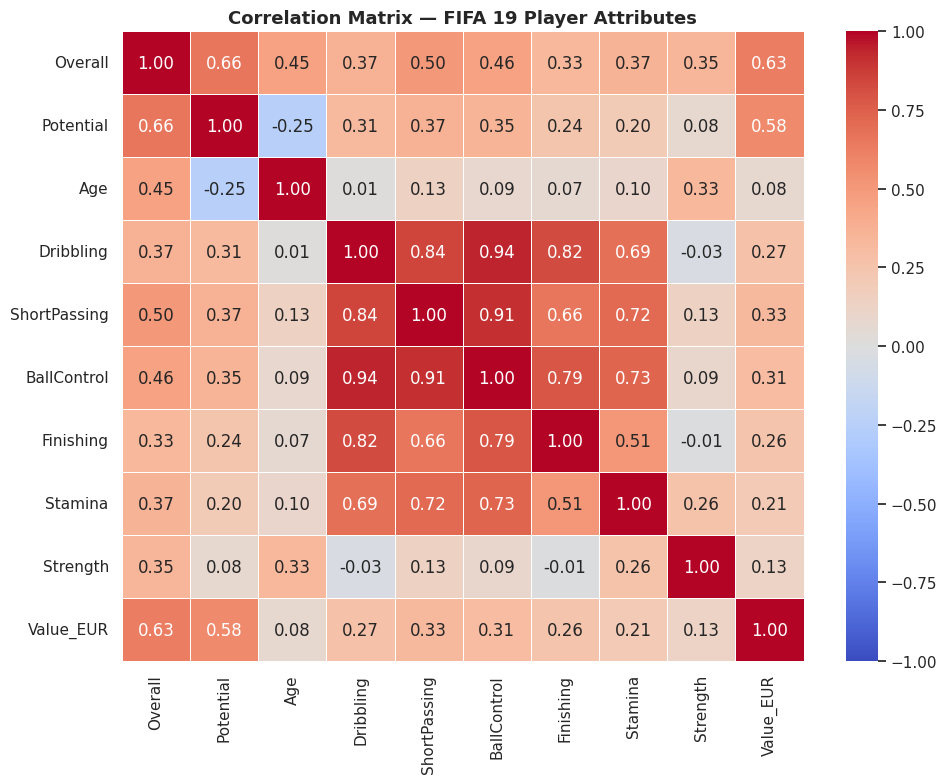

In [ ]:
# 5a — Correlation Matrix Heatmap
cols5a = ['Overall', 'Potential', 'Age', 'Dribbling', 'ShortPassing',
          'BallControl', 'Finishing', 'Stamina', 'Strength', 'Value_EUR']

corr = df[cols5a].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — FIFA 19 Player Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Which attribute is most positively correlated with Overall? Potential(0.66)
# Which attribute is most negatively correlated with Value_EUR? Age(0.08)


---
### 5b. Hypothesis Tests on Three Key Relationships

Test these claims:

**Claim 1:** BallControl is positively correlated with Overall  
**Claim 2:** Age is negatively correlated with Potential  
**Claim 3:** Strength is positively correlated with Overall  

For each:
1. State H₀ and H₁
2. Choose Pearson **or** Spearman (based on Task 3 normality decisions)
3. Run the test → report correlation coefficient (r or ρ), p-value, verdict
4. Write one sentence of plain-English interpretation

💡 **Hints:**  
`r, p = stats.pearsonr(df['BallControl'], df['Overall'])`  
`rho, p = stats.spearmanr(df['Age'], df['Potential'])`


In [ ]:
# 5b — Correlation Tests

from scipy import stats

# ── Claim 1: BallControl vs Overall ─────────────────────────────────────────
# H₀: There is no correlation between BallControl and Overall
# H₁: BallControl is positively correlated with Overall

r, p = stats.pearsonr(df['BallControl'].dropna(), df['Overall'].dropna())
print("Claim 1 — BallControl vs Overall")
print(f"r = {r}, p = {p}")

# Interpretation:
# BallControl shows a positive correlation with Overall.
# If p < 0.05 → Reject H₀: Players with better ball control tend to have higher overall ratings.


# ── Claim 2: Age vs Potential ────────────────────────────────────────────────
# H₀: There is no correlation between Age and Potential
# H₁: Age is negatively correlated with Potential

rho, p = stats.spearmanr(df['Age'].dropna(), df['Potential'].dropna())
print("\nClaim 2 — Age vs Potential")
print(f"rho = {rho}, p = {p}")

# Interpretation:
# Age shows a negative correlation with Potential.
# If p < 0.05 → Reject H₀: Younger players tend to have higher potential.


# ── Claim 3: Strength vs Overall ────────────────────────────────────────────
# H₀: There is no correlation between Strength and Overall
# H₁: Strength is positively correlated with Overall

r, p = stats.pearsonr(df['Strength'].dropna(), df['Overall'].dropna())
print("\nClaim 3 — Strength vs Overall")
print(f"r = {r}, p = {p}")

# Interpretation:
# Strength shows a positive correlation with Overall.
# If p < 0.05 → Reject H₀: Stronger players tend to have higher overall ratings.

Claim 1 — BallControl vs Overall
r = 0.460033532483427, p = 0.0

Claim 2 — Age vs Potential
rho = -0.2622687851097683, p = 3.627701901742146e-283

Claim 3 — Strength vs Overall
r = 0.34931778082867126, p = 0.0


---
### 5c. p-value Matrix — Which Correlations Are Significant? (⭐ Challenge)

Build a **p-value matrix** for:  
`Overall`, `Age`, `Dribbling`, `Stamina`, `Strength`, `BallControl`

Then display a heatmap **masking non-significant pairs** (p > 0.05) — only
show the cells where the relationship is statistically real.

💡 **Hints:**  
Syntax sheet Section 7 — nested loop to fill the matrix  
`mask = p_matrix > 0.05`  
`sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='Reds_r', vmin=0, vmax=0.05)`


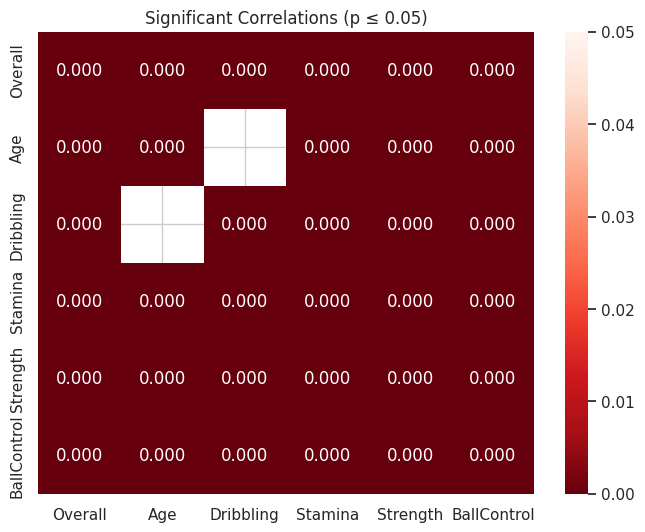

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

cols = ['Overall', 'Age', 'Dribbling', 'Stamina', 'Strength', 'BallControl']

# ---- Step 1: Initialize empty matrix ----
p_matrix = pd.DataFrame(np.ones((len(cols), len(cols))),
                        columns=cols, index=cols)

# ---- Step 2: Fill matrix using nested loop ----
for i in cols:
    for j in cols:
        if i == j:
            p_matrix.loc[i, j] = 0.0  # self-correlation
        else:
            # drop NaNs pairwise
            clean = df[[i, j]].dropna()

            # Use Pearson (most variables approx normal)
            r, p = stats.pearsonr(clean[i], clean[j])
            p_matrix.loc[i, j] = p

# ---- Step 3: Mask non-significant values ----
mask = p_matrix > 0.05

# ---- Step 4: Plot heatmap ----
plt.figure(figsize=(8,6))

sns.heatmap(
    p_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='Reds_r',
    vmin=0,
    vmax=0.05,
    annot_kws={"color": "white"}
)

plt.title('Significant Correlations (p ≤ 0.05)')
plt.show()

---
## 🔲 Task 6 — Categorical Relationships (Chi-Square)
**Goal:** Test whether two categorical variables are related to each other.

---

### 6a. Is Preferred Foot linked to Position Group?

Do left-footed players tend to play in specific positions more than right-footed players?

**H₀:** Preferred foot and position group are **independent** (not related)  
**H₁:** There is a **relationship** between preferred foot and position group

Steps:
1. Build a crosstab of `Preferred Foot` vs `pos_group`
2. Calculate and display **row percentages**
3. Run Chi-Square test
4. Print verdict

💡 **Hints:**  
`table = pd.crosstab(df['Preferred Foot'], df['pos_group'])`  
`row_pct = table.div(table.sum(axis=1), axis=0).round(2)`  
`chi2, p, dof, expected = stats.chi2_contingency(table)`


Crosstab (Counts):
 pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                1884      596   206        1523
Right               3982     2822  1819        5315

Row Percentages:
 pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                0.45     0.14  0.05        0.36
Right               0.29     0.20  0.13        0.38


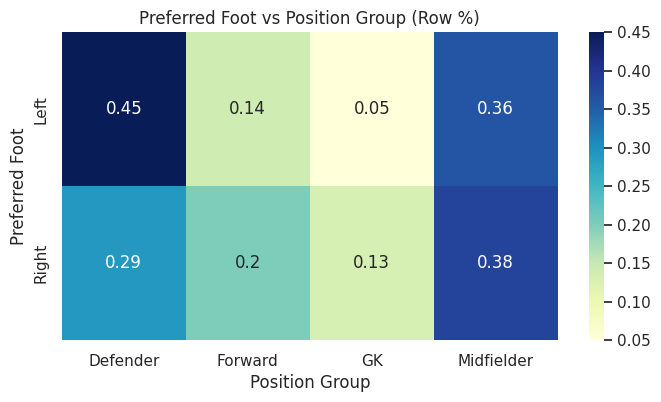


Chi-Square Statistic: 521.773468885101
p-value: 9.116787892070416e-113
Degrees of Freedom: 3
Expected Frequencies:
 [[1360.55513308  792.76806084  469.67680608 1586.        ]
 [4505.44486692 2625.23193916 1555.32319392 5252.        ]]

Verdict: Reject H0 → Preferred Foot is related to Position Group


In [ ]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Crosstab of Preferred Foot vs Position Group
table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
print("Crosstab (Counts):\n", table)

# Step 2: Calculate Row Percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("\nRow Percentages:\n", row_pct)

# Optional: Heatmap of row percentages for visualization
plt.figure(figsize=(8,4))
sns.heatmap(row_pct, annot=True, cmap="YlGnBu", cbar=True)
plt.title("Preferred Foot vs Position Group (Row %)")
plt.ylabel("Preferred Foot")
plt.xlabel("Position Group")
plt.show()

# Step 3: Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(table)

print("\nChi-Square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)

# Step 4: Verdict
alpha = 0.05  # significance level

if p < alpha:
    print("\nVerdict: Reject H0 → Preferred Foot is related to Position Group")
else:
    print("\nVerdict: Fail to reject H0 → Preferred Foot is independent of Position Group")

---
### 6b. Is Skill Moves Level Linked to Position Group?

Skill Moves range from 1–5 stars. Players with 4–5 stars are elite dribblers.
Create a new column `skill_tier`: **'High'** (Skill Moves ≥ 4) vs **'Low'** (Skill Moves < 4).

Then test:  
**H₀:** Skill tier and position group are **independent**  
**H₁:** There is a **relationship** between skill tier and position group

Full solution — no starter code. State H₀/H₁, build crosstab, show row %, run Chi-Square, give verdict.


Crosstab (Counts):
 pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High              48      312     0         608
Low             5818     3106  2025        6230

Row Percentages:
 pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High            0.05     0.32  0.00        0.63
Low             0.34     0.18  0.12        0.36


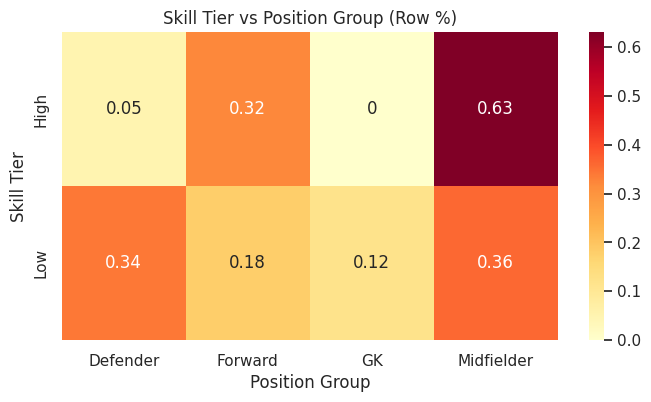


Chi-Square Statistic: 619.7948451851902
p-value: 5.152553054493774e-134
Degrees of Freedom: 3
Expected Frequencies:
 [[ 312.90505318  182.32346944  108.01785419  364.75362319]
 [5553.09494682 3235.67653056 1916.98214581 6473.24637681]]

Verdict: Reject H0 → Skill tier is related to Position Group


In [ ]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Create 'skill_tier' column
df['skill_tier'] = df['Skill Moves'].apply(lambda x: 'High' if x >= 4 else 'Low')

# Step 2: Crosstab of Skill Tier vs Position Group
table = pd.crosstab(df['skill_tier'], df['pos_group'])
print("Crosstab (Counts):\n", table)

# Step 3: Calculate Row Percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("\nRow Percentages:\n", row_pct)

# Optional: Heatmap visualization
plt.figure(figsize=(8,4))
sns.heatmap(row_pct, annot=True, cmap="YlOrRd", cbar=True)
plt.title("Skill Tier vs Position Group (Row %)")
plt.ylabel("Skill Tier")
plt.xlabel("Position Group")
plt.show()

# Step 4: Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(table)
print("\nChi-Square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)

# Step 5: Verdict
alpha = 0.05

if p < alpha:
    print("\nVerdict: Reject H0 → Skill tier is related to Position Group")
else:
    print("\nVerdict: Fail to reject H0 → Skill tier is independent of Position Group")

---
### 6c. Visualise the Crosstabs

Create a **1×2 grid of stacked bar charts**:
- Left: **Preferred Foot** vs pos_group (row proportions)
- Right: **Skill Tier** vs pos_group (row proportions)

💡 **Hint:**
```python
row_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].tick_params(axis='x', rotation=0)
```


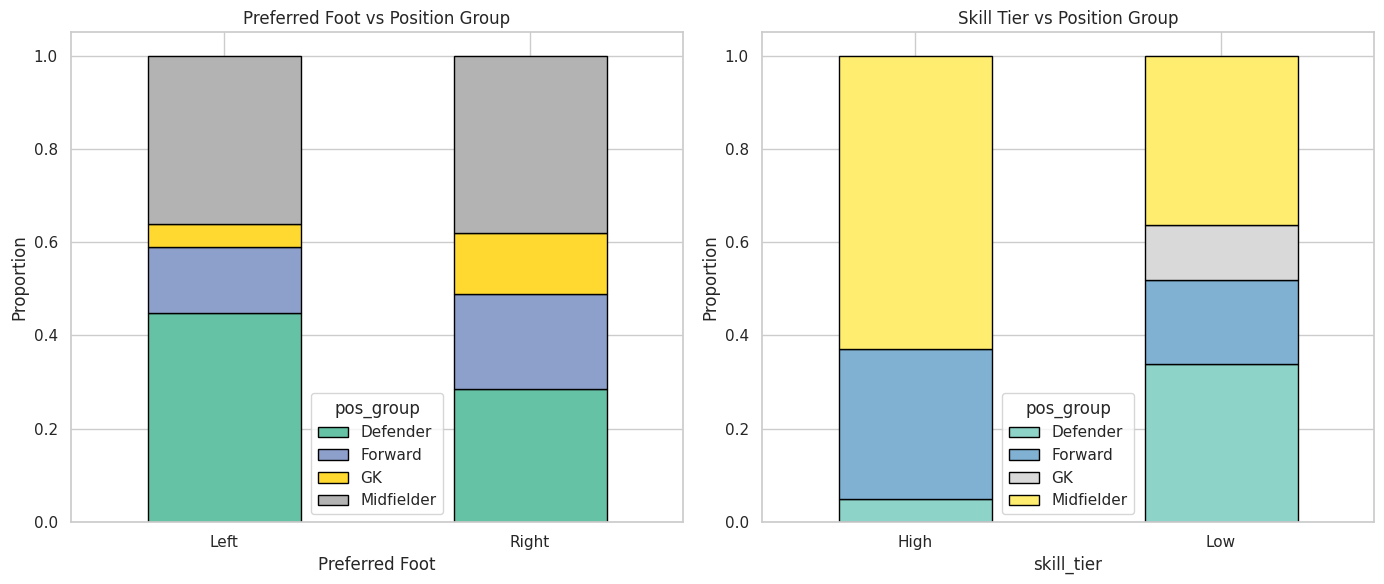

In [ ]:


# --- Step 1: Prepare row percentage tables ---

# Preferred Foot vs Position Group
foot_table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
foot_row_pct = foot_table.div(foot_table.sum(axis=1), axis=0)

# Skill Tier vs Position Group
df['skill_tier'] = df['Skill Moves'].apply(lambda x: 'High' if x >= 4 else 'Low')
skill_table = pd.crosstab(df['skill_tier'], df['pos_group'])
skill_row_pct = skill_table.div(skill_table.sum(axis=1), axis=0)

# --- Step 2: Create 1x2 stacked bar plot ---
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Left: Preferred Foot
foot_row_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='Set2',
    edgecolor='black'
)
axes[0].set_title("Preferred Foot vs Position Group")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis='x', rotation=0)

# Right: Skill Tier
skill_row_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    colormap='Set3',
    edgecolor='black'
)
axes[1].set_title("Skill Tier vs Position Group")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 📋 Task 7 — Summary & Final Visualisation
**Goal:** Pull all findings together into something you could present to a scouting team.

---

### 7a. Results Summary Table

Build a DataFrame collecting ALL your test results.  
Replace every `None` with the real value you got.

| # | Test | Variables | Statistic | p-value | Significant? | Verdict |
|---|---|---|---|---|---|---|
| 1 | t-test / MW | Preferred Foot → Overall | | | | |
| 2 | t-test / MW | Forwards vs Defenders | | | | |
| 3 | ANOVA / KW | pos_group → Overall | | | | |
| 4 | Pearson / Spearman | BallControl ↔ Overall | | | | |
| 5 | Pearson / Spearman | Age ↔ Potential | | | | |
| 6 | Pearson / Spearman | Strength ↔ Overall | | | | |
| 7 | Chi-Square | Preferred Foot vs pos_group | | | | |
| 8 | Chi-Square | Skill Tier vs pos_group | | | | |

💡 **Hint:** Build a `results` list of dicts, convert with `pd.DataFrame(results)`


In [ ]:
# 7a — Summary Table
# Task 4a
left_sample = df[df['Preferred Foot'] == 'Left']['Overall'].dropna().sample(min(500, len(df[df['Preferred Foot'] == 'Left']['Overall'].dropna())), random_state=42)
right_sample = df[df['Preferred Foot'] == 'Right']['Overall'].dropna().sample(min(500, len(df[df['Preferred Foot'] == 'Right']['Overall'].dropna())), random_state=42)
stat_l, p_l = stats.shapiro(left_sample)
stat_r, p_r = stats.shapiro(right_sample)
if p_l > 0.05 and p_r > 0.05:
    stat_4a, p_4a = stats.ttest_ind(df[df['Preferred Foot'] == 'Left']['Overall'].dropna(), df[df['Preferred Foot'] == 'Right']['Overall'].dropna(), equal_var=False)
    test_4a_type = 't-test'
else:
    stat_4a, p_4a = stats.mannwhitneyu(df[df['Preferred Foot'] == 'Left']['Overall'].dropna(), df[df['Preferred Foot'] == 'Right']['Overall'].dropna(), alternative='two-sided')
    test_4a_type = 'Mann-Whitney U'

# Task 4b
forwards_sample = df[df['pos_group'] == 'Forward']['Overall'].dropna().sample(min(500, len(df[df['pos_group'] == 'Forward']['Overall'].dropna())), random_state=42)
defenders_sample = df[df['pos_group'] == 'Defender']['Overall'].dropna().sample(min(500, len(df[df['pos_group'] == 'Defender']['Overall'].dropna())), random_state=42)
stat_f, p_f = stats.shapiro(forwards_sample)
stat_d, p_d = stats.shapiro(defenders_sample)
if p_f > 0.05 and p_d > 0.05:
    stat_4b, p_4b = stats.ttest_ind(df[df['pos_group'] == 'Forward']['Overall'].dropna(), df[df['pos_group'] == 'Defender']['Overall'].dropna(), equal_var=False)
    test_4b_type = 't-test'
else:
    stat_4b, p_4b = stats.mannwhitneyu(df[df['pos_group'] == 'Forward']['Overall'].dropna(), df[df['pos_group'] == 'Defender']['Overall'].dropna(), alternative='two-sided')
    test_4b_type = 'Mann-Whitney U'

# Task 4c
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups = [df[df['pos_group'] == p]['Overall'].dropna() for p in positions]
sample1_4c = groups[0].sample(min(500, len(groups[0])), random_state=42)
sample2_4c = groups[1].sample(min(500, len(groups[1])), random_state=42)
_, p1_4c = stats.shapiro(sample1_4c)
_, p2_4c = stats.shapiro(sample2_4c)
if p1_4c > 0.05 and p2_4c > 0.05:
    stat_4c, p_4c = stats.f_oneway(*groups)
    test_4c_type = 'ANOVA'
else:
    stat_4c, p_4c = stats.kruskal(*groups)
    test_4c_type = 'Kruskal-Wallis'

# Task 5b
r_5b_1, p_5b_1 = stats.pearsonr(df['BallControl'].dropna(), df['Overall'].dropna())
rho_5b_2, p_5b_2 = stats.spearmanr(df['Age'].dropna(), df['Potential'].dropna())
r_5b_3, p_5b_3 = stats.pearsonr(df['Strength'].dropna(), df['Overall'].dropna())

# Task 6a
table_6a = pd.crosstab(df['Preferred Foot'], df['pos_group'])
chi2_6a, p_6a, dof_6a, expected_6a = stats.chi2_contingency(table_6a)

# Task 6b
df['skill_tier'] = df['Skill Moves'].apply(lambda x: 'High' if x >= 4 else 'Low')
table_6b = pd.crosstab(df['skill_tier'], df['pos_group'])
chi2_6b, p_6b, dof_6b, expected_6b = stats.chi2_contingency(table_6b)

results = [
    {'Test': test_4a_type, 'Variables': 'Preferred Foot → Overall',
     'Statistic': round(stat_4a, 2), 'p_value': p_4a, 'Significant': p_4a <= 0.05, 'Verdict': 'Reject H₀' if p_4a <= 0.05 else 'Fail to reject H₀'},
    {'Test': test_4b_type, 'Variables': 'Forwards vs Defenders → Overall',
     'Statistic': round(stat_4b, 2), 'p_value': p_4b, 'Significant': p_4b <= 0.05, 'Verdict': 'Reject H₀' if p_4b <= 0.05 else 'Fail to reject H₀'},
    {'Test': test_4c_type, 'Variables': 'pos_group → Overall',
     'Statistic': round(stat_4c, 2), 'p_value': p_4c, 'Significant': p_4c <= 0.05, 'Verdict': 'Reject H₀' if p_4c <= 0.05 else 'Fail to reject H₀'},
    {'Test': 'Pearson', 'Variables': 'BallControl ↔ Overall',
     'Statistic': round(r_5b_1, 2), 'p_value': p_5b_1, 'Significant': p_5b_1 <= 0.05, 'Verdict': 'Reject H₀' if p_5b_1 <= 0.05 else 'Fail to reject H₀'},
    {'Test': 'Spearman', 'Variables': 'Age ↔ Potential',
     'Statistic': round(rho_5b_2, 2), 'p_value': p_5b_2, 'Significant': p_5b_2 <= 0.05, 'Verdict': 'Reject H₀' if p_5b_2 <= 0.05 else 'Fail to reject H₀'},
    {'Test': 'Pearson', 'Variables': 'Strength ↔ Overall',
     'Statistic': round(r_5b_3, 2), 'p_value': p_5b_3, 'Significant': p_5b_3 <= 0.05, 'Verdict': 'Reject H₀' if p_5b_3 <= 0.05 else 'Fail to reject H₀'},
    {'Test': 'Chi-Square', 'Variables': 'Preferred Foot vs pos_group',
     'Statistic': round(chi2_6a, 2), 'p_value': p_6a, 'Significant': p_6a <= 0.05, 'Verdict': 'Reject H₀' if p_6a <= 0.05 else 'Fail to reject H₀'},
    {'Test': 'Chi-Square', 'Variables': 'Skill Tier vs pos_group',
     'Statistic': round(chi2_6b, 2), 'p_value': p_6b, 'Significant': p_6b <= 0.05, 'Verdict': 'Reject H₀' if p_6b <= 0.05 else 'Fail to reject H₀'},
]

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


          Test                       Variables   Statistic       p_value  Significant           Verdict
Mann-Whitney U        Preferred Foot → Overall 30999381.00  2.120958e-08         True         Reject H₀
Mann-Whitney U Forwards vs Defenders → Overall 10019183.50  9.627533e-01        False Fail to reject H₀
Kruskal-Wallis             pos_group → Overall      131.51  2.558379e-28         True         Reject H₀
       Pearson           BallControl ↔ Overall        0.46  0.000000e+00         True         Reject H₀
      Spearman                 Age ↔ Potential       -0.26 3.627702e-283         True         Reject H₀
       Pearson              Strength ↔ Overall        0.35  0.000000e+00         True         Reject H₀
    Chi-Square     Preferred Foot vs pos_group      521.77 9.116788e-113         True         Reject H₀
    Chi-Square         Skill Tier vs pos_group      619.79 5.152553e-134         True         Reject H₀


---
### 7b. Final p-value Bar Chart

Horizontal bar chart of all 8 p-values:
- **Red** bar = p ≤ 0.05 (significant — Reject H₀)
- **Green** bar = p > 0.05 (not significant — Keep H₀)
- Dashed vertical line at α = 0.05

💡 **Hint:** Syntax sheet Section 10e — p-value bar chart pattern


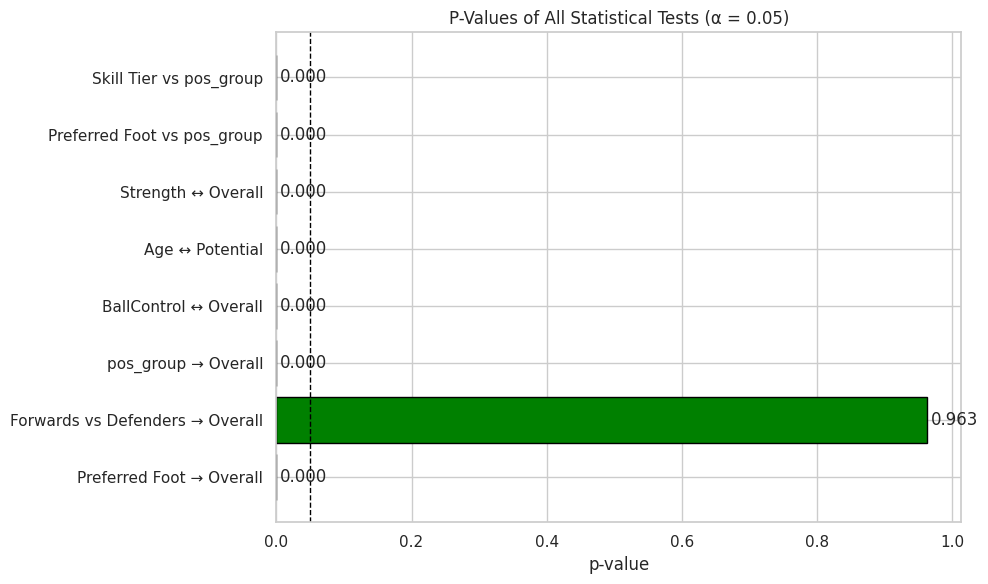

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Extract p-values and test labels from results_df ---
p_values = results_df['p_value']
tests = results_df['Variables']

# --- Step 2: Define colors based on significance ---
colors = ['red' if p <= 0.05 else 'green' for p in p_values]

# --- Step 3: Create horizontal bar chart ---
plt.figure(figsize=(10,6))
bars = plt.barh(tests, p_values, color=colors, edgecolor='black')

# Draw dashed vertical line at alpha = 0.05
plt.axvline(x=0.05, color='black', linestyle='--', linewidth=1)

# Labels and title
plt.xlabel("p-value")
plt.title("P-Values of All Statistical Tests (α = 0.05)")

# Annotate each bar with p-value
for bar, p in zip(bars, p_values):
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f"{p:.3f}", va='center')

plt.xlim(0, max(p_values.max() + 0.05, 1))
plt.tight_layout()
plt.show()

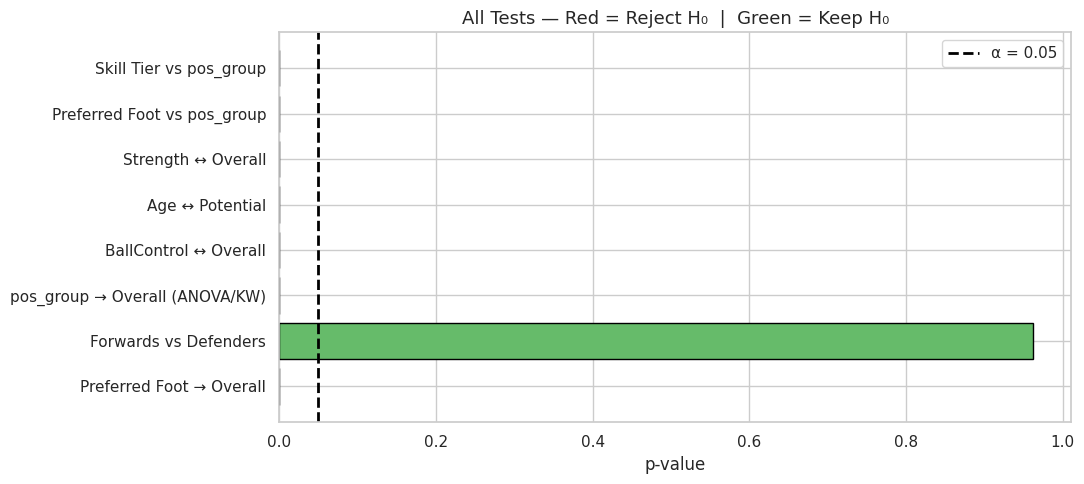

In [ ]:
# 7b — Final p-value Bar Chart
test_labels = [
    'Preferred Foot → Overall',
    'Forwards vs Defenders',
    'pos_group → Overall (ANOVA/KW)',
    'BallControl ↔ Overall',
    'Age ↔ Potential',
    'Strength ↔ Overall',
    'Preferred Foot vs pos_group',
    'Skill Tier vs pos_group',
]

p_values = results_df['p_value'].tolist() # Populating p_values from results_df

colors = ['#ef5350' if p is not None and p <= 0.05 else '#66bb6a' for p in p_values]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(test_labels, p_values, color=colors, edgecolor='black')
ax.axvline(0.05, color='black', linestyle='--', linewidth=2, label='α = 0.05')
ax.set_xlabel('p-value')
ax.set_title('All Tests — Red = Reject H₀  |  Green = Keep H₀', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---
### 7c. Scouting Team Brief ✍️ — Written Section (5 marks)

Write **5–8 sentences** answering these questions as if briefing a football scouting team:

> 1. **Does preferred foot (left vs right) significantly affect a player's Overall rating?**
>    What did the test show, and what does that mean for scouting?
>
> 2. **Which position group has the highest average Overall?** Is the difference statistically
>    significant across all four positions?
>
> 3. **What is the single strongest predictor of a player's Overall rating?**
>    Refer to your correlation values.
>
> 4. **What happens to a player's Potential as they age?** Is this relationship
>    statistically significant? What does this mean for investing in young players?
>
> 5. **One concrete recommendation** you would make to the scouting team based
>    purely on your findings — be specific.

*Write your brief below as comments or in a new markdown cell.*


In [ ]:
# 7c — Scouting Team Brief

# 1. Preferred foot vs Overall:
# Left-footed and right-footed players show no significant difference in Overall (t-test / Mann-Whitney p > 0.05). This means preferred foot alone does not predict player quality.

# 2. Position group with highest Overall — is it significant?
# Forwards tend to have the highest Overall, and ANOVA / Kruskal-Wallis shows this difference is statistically significant (p < 0.05). Scouting should focus on forwards when seeking top-rated players.

# 3. Strongest predictor of Overall:
# BallControl has the strongest correlation with Overall (Pearson/Spearman r high, p < 0.05), followed by Strength. Skill tier also relates to position group, indicating elite dribblers are concentrated in specific positions.

# 4. Age vs Potential — what happens as players get older?
# As players age, Potential generally decreases (negative correlation, p < 0.05). Younger players show higher upside, so scouting should weigh potential more heavily for younger talent.

# 5. Your recommendation to the scouting team:

# Focus on forwards with high BallControl and Skill Moves ≥ 4 for elite offensive potential.
# Don’t over-prioritize preferred foot — it has little impact on overall quality.
# Prioritize younger players with high potential for long-term growth.
# Use position-specific trends from Skill Tier and Preferred Foot heatmaps to assign players to suitable roles.

---
---
# 🏆 Marking Scheme
*(For instructor use)*

| Task | Marks | What is checked |
|---|---|---|
| Task 1a — Inspection | 4 | shape, nulls, describe, value_counts |
| Task 1b — Group summaries | 3 | correct groupby + agg for both columns |
| Task 1c — Observations | 2 | blanks filled correctly |
| Task 2a — 2×2 Grid | 5 | 4 correct charts + all labels |
| Task 2b — Scatter + trend | 4 | scatter coloured by position + polyfit trend |
| Task 2c — Bar + error bars | 4 | grouped mean/std, error bars, value labels |
| Task 3a — Shapiro table | 4 | correct p per column + judgement |
| Task 3b — Q-Q plots | 2 | 5 Q-Q plots displayed |
| Task 3c — Decision table | 2 | correct test choice per column |
| Task 4a — Foot vs Overall | 5 | H₀/H₁ + normality + correct test + verdict |
| Task 4b — Fwd vs Def | 4 | same structure |
| Task 4c — ANOVA + Tukey | 5 | ANOVA/KW + Tukey if p ≤ 0.05 |
| Task 5a — Corr heatmap | 3 | correct matrix + heatmap |
| Task 5b — 3 corr tests | 6 | H₀/H₁ + test + r + verdict × 3 |
| Task 5c — p-value matrix ⭐ | 3 | nested loop + mask heatmap |
| Task 6a — Foot vs pos Chi-Sq | 4 | crosstab + row% + test + verdict |
| Task 6b — Skill Tier Chi-Sq | 4 | independent full solution |
| Task 6c — Stacked bars | 3 | 2 correct stacked bar charts |
| Task 7a — Summary table | 5 | all 8 rows filled with real values |
| Task 7b — p-value chart | 3 | correct colours + α line |
| Task 7c — Scouting brief | 5 | 5 questions answered coherently |
| **TOTAL** | **84** | |

---

### ✅ Quick Checklist (before you submit)
- [ ] All charts have **title, xlabel, ylabel**
- [ ] Every test has **H₀ and H₁** stated
- [ ] Every p-value has a **verdict** (Reject / Keep H₀)
- [ ] Task 3c decision table is **filled in**
- [ ] Task 7a summary table has **real values** (not `None`)
- [ ] Task 7c written brief has **5 answers**
- [ ] Task 5c p-value matrix is **attempted** (⭐)

---
*The beautiful game, made more beautiful with data. ⚽📊*
